In [ ]:
### Step 1: Import Libraries and Generate Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# Create a synthetic regression dataset
X, y = make_regression(n_samples=100, n_features=20, n_informative=5, noise=10, random_state=42)

print(f"Dataset Shape: X={X.shape}, y={y.shape}")

Dataset Shape: X=(100, 20), y=(100,)


In [ ]:
### Step 2: Data Splitting and Scaling
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
### Step 3: Linear Regression (Baseline Model)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions and calculate error
lr_preds = lr_model.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_preds)

print(f"Linear Regression MSE: {lr_mse:.2f}")

Linear Regression MSE: 232.83


In [ ]:
### Step 4: Ridge Regression (L2 Regularization)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Predictions and evaluation
ridge_preds = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_preds)

print(f"Ridge Regression MSE: {ridge_mse:.2f}")
print("Ridge Coefficients (Notice none are exactly 0):")
print(np.round(ridge_model.coef_, 2))

Ridge Regression MSE: 229.59
Ridge Coefficients (Notice none are exactly 0):
[ 8.87 -0.58 34.54  0.6  -1.53  0.28  9.85 -0.88 71.53 39.09 -1.89 -1.58
 -2.17  1.08  1.06 -2.6   0.44  0.1   1.37 -1.64]


In [ ]:
### Step 5: Lasso Regression (L1 Regularization)
# Train Lasso model (alpha = 1.0)
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)

# Predictions and error calculation
lasso_preds = lasso_model.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_preds)

print(f"Lasso Regression MSE: {lasso_mse:.2f}")
print("Lasso Coefficients (Notice many are exactly 0 - Feature Selection):")
print(np.round(lasso_model.coef_, 2))

Lasso Regression MSE: 139.61
Lasso Coefficients (Notice many are exactly 0 - Feature Selection):
[ 6.77 -0.   34.12  0.   -0.   -0.    9.03 -0.   71.44 37.86 -0.63 -0.
 -0.58  0.    0.42 -1.55  0.   -0.    0.72 -0.  ]


In [ ]:
### Step 6: ElasticNet Regression (L1 + L2 combined)
# l1_ratio=0.5 means equal weight to L1 and L2 penalties
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic_model.fit(X_train_scaled, y_train)

# Predictions and evaluation
elastic_preds = elastic_model.predict(X_test_scaled)
elastic_mse = mean_squared_error(y_test, elastic_preds)

print(f"ElasticNet MSE: {elastic_mse:.2f}")
print("ElasticNet Coefficients:")
print(np.round(elastic_model.coef_, 2))

ElasticNet MSE: 1095.32
ElasticNet Coefficients:
[ 2.690e+00  8.000e-02  2.085e+01  1.600e+00 -0.000e+00 -3.300e-01
  3.590e+00  8.700e-01  4.744e+01  2.938e+01 -2.740e+00  1.300e+00
  6.900e-01 -3.400e-01  2.250e+00 -3.420e+00 -1.490e+00  3.000e-02
  2.090e+00  0.000e+00]


In [ ]:
### Step 7: Hyperparameter Tuning for Ridge
# Define alpha values to test
alpha_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# Setup GridSearchCV (5-fold cross-validation)
ridge_cv = GridSearchCV(Ridge(), alpha_params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

# Identify best alpha and model
best_alpha = ridge_cv.best_params_['alpha']
best_ridge_model = ridge_cv.best_estimator_

# Final prediction with optimized model
best_ridge_preds = best_ridge_model.predict(X_test_scaled)
best_ridge_mse = mean_squared_error(y_test, best_ridge_preds)

print(f"Best Alpha for Ridge: {best_alpha}")
print(f"Optimized Ridge Regression MSE: {best_ridge_mse:.2f}")

Best Alpha for Ridge: 0.1
Optimized Ridge Regression MSE: 232.34


In [ ]:
### Step 8: Optimizing ElasticNet with GridSearchCV
from sklearn.linear_model import ElasticNet

# Define parameter grid for ElasticNet
en_params = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Perform Grid Search
en_cv = GridSearchCV(ElasticNet(), en_params, cv=5, scoring='neg_mean_squared_error')
en_cv.fit(X_train_scaled, y_train)

# Extract best parameters and model
best_en_alpha = en_cv.best_params_['alpha']
best_en_l1 = en_cv.best_params_['l1_ratio']
best_en_model = en_cv.best_estimator_

# Evaluate optimized model
best_en_preds = best_en_model.predict(X_test_scaled)
best_en_mse = mean_squared_error(y_test, best_en_preds)

print(f"Best Params for ElasticNet: Alpha={best_en_alpha}, l1_ratio={best_en_l1}")
print(f"Optimized ElasticNet MSE: {best_en_mse:.2f}")

Best Params for ElasticNet: Alpha=0.1, l1_ratio=0.9
Optimized ElasticNet MSE: 219.23


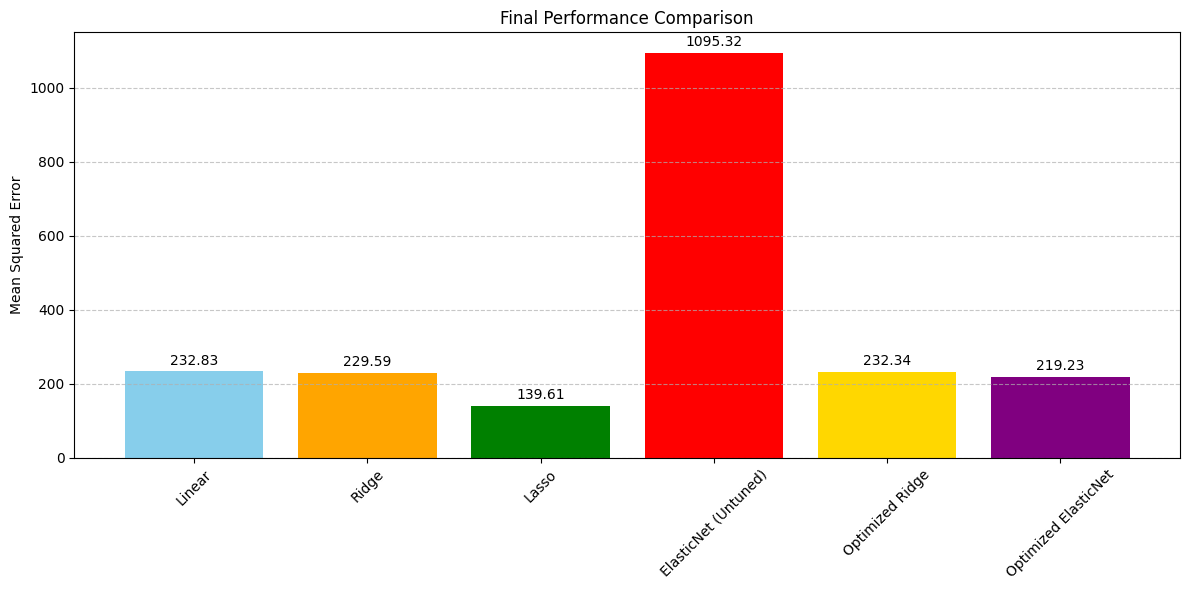

In [ ]:
### Step 9: Re-compare all models including Optimized ElasticNet
updated_models = ['Linear', 'Ridge', 'Lasso', 'ElasticNet (Untuned)', 'Optimized Ridge', 'Optimized ElasticNet']
updated_mse = [lr_mse, ridge_mse, lasso_mse, elastic_mse, best_ridge_mse, best_en_mse]

plt.figure(figsize=(12, 6))
bars = plt.bar(updated_models, updated_mse, color=['skyblue', 'orange', 'green', 'red', 'gold', 'purple'])

plt.ylabel('Mean Squared Error')
plt.title('Final Performance Comparison')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, round(yval, 2), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

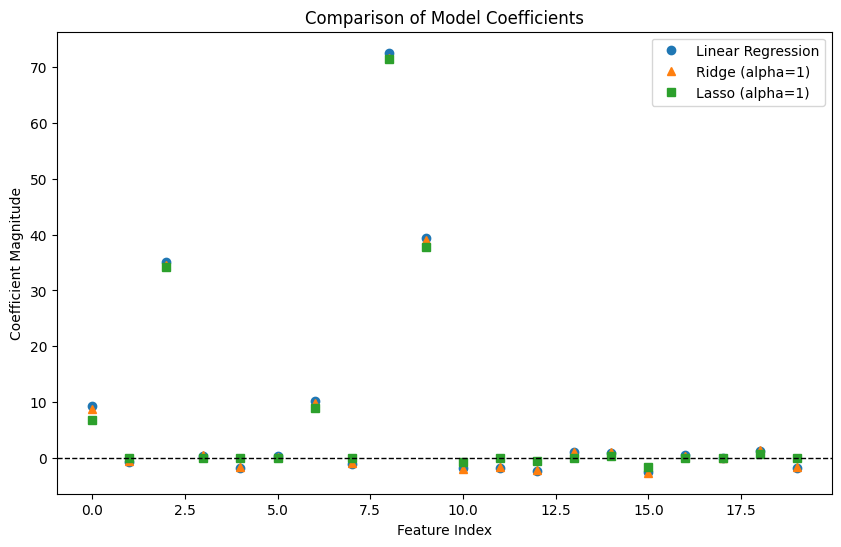

In [ ]:
### Step 10: Visualization - Comparison of Coefficients
plt.figure(figsize=(10, 6))

plt.plot(lr_model.coef_, 'o', label='Linear Regression')
plt.plot(ridge_model.coef_, '^', label='Ridge (alpha=1)')
plt.plot(lasso_model.coef_, 's', label='Lasso (alpha=1)')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Magnitude')
plt.title('Comparison of Model Coefficients')
plt.legend()
plt.show()

# **1. Linear Regression (Circles)**
The blue circles represent the baseline coefficients. These values are often the largest in magnitude because they have no penalty for complexity.
They act as a reference point for how much the other models 'shrink' the feature weights.

# **2. Ridge Regression (Triangles)**
The orange triangles represent Ridge (L2) regularization.
Notice how they are generally closer to the zero line than the Linear Regression circles. Ridge penalizes the square of the coefficients, forcing them to be smaller but never exactly zero. This helps reduce model sensitivity to noise.

# **3. Lasso Regression (Squares)**
The green squares represent Lasso (L1) regularization.
This is the most striking part of the plot: many of the squares sit exactly on the zero line. Lasso penalizes the absolute value of coefficients, which can force less important features to zero.
In your output, Lasso achieved the lowest MSE (139.61), suggesting that for this specific dataset, removing irrelevant features (feature selection) was more effective than just shrinking them.